# CSQA Answer-Choice Tuned Lens Analysis

This notebook analyzes CommonsenseQA in a single methodology:

- tuned-lens style preparation first
- only the constrained A-E answer-choice decision space
- layerwise trace analysis after the tuned readout is ready

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

from src.data.load_csqa import load_csqa

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

/home/ubuntu/Transformer-Decision-Traces/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
TRAIN_SPLIT = "train"
EVAL_SPLIT = "validation"
TRAIN_LIMIT = 4096
EVAL_LIMIT = None
MAX_SEQ_LEN = 384
EXTRACT_BATCH_SIZE = 2
ATTENTION_BATCH_SIZE = 1
RESIDUAL_SUBSTEP_BATCH_SIZE = 1
TUNED_LENS_BATCH_SIZE = 64
TUNED_LENS_EPOCHS = 3
TUNED_LENS_LR = 5e-4
TUNED_LENS_WEIGHT_DECAY = 1e-5
SEED = 42
USE_BFLOAT16_IF_AVAILABLE = True
ANSWER_CHOICE_ENTROPY_SATURATION_THRESHOLD = 0.25
ANSWER_CHOICE_GAP_STABILITY_THRESHOLD = 3.0

## Data And Model Setup

The tuned lens is trained on cached hidden states. The base model itself stays frozen.


In [3]:
torch.manual_seed(SEED)
np.random.seed(SEED)

LETTERS = ["A", "B", "C", "D", "E"]

train_rows = load_csqa(split=TRAIN_SPLIT, limit=TRAIN_LIMIT).copy()
eval_rows = load_csqa(split=EVAL_SPLIT, limit=EVAL_LIMIT).copy()

for frame in [train_rows, eval_rows]:
    frame["n_choices"] = frame["csqa_choices"].map(len)
    frame["prompt_len_chars"] = frame["text"].str.len()
    assert frame["n_choices"].eq(5).all(), "Expected 5 choices for every CSQA row."

if torch.cuda.is_available():
    if USE_BFLOAT16_IF_AVAILABLE and torch.cuda.is_bf16_supported():
        model_dtype = torch.bfloat16
    else:
        model_dtype = torch.float16
    device_map = "auto"
else:
    model_dtype = torch.float32
    device_map = None

tok = AutoTokenizer.from_pretrained(MODEL_ID)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=model_dtype,
    device_map=device_map,
    attn_implementation="eager",
)
model.eval()


def build_answer_token_ids(tok):
    out = {}
    for letter in LETTERS:
        ids = tok(" " + letter, add_special_tokens=False)["input_ids"]
        if len(ids) != 1:
            raise ValueError(f"Answer token '{letter}' is not single-token: {ids}")
        out[letter] = int(ids[0])
    return out


answer_token_ids = build_answer_token_ids(tok)
answer_ids = [answer_token_ids[l] for l in LETTERS]
answer_id_tensor = torch.tensor(answer_ids, dtype=torch.long)

display(train_rows[["example_id", "answerKey", "prompt_len_chars"]].head())
print("train rows:", len(train_rows))
print("eval rows:", len(eval_rows))
print("answer token ids:", answer_token_ids)


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 434/434 [00:46<00:00,  9.42it/s]


,example_id,answerKey,prompt_len_chars
0,42ed410d54eae473eb4578d8550259ed,A,200
1,a7059f15c9a41e642c05358ee3bfdad5,B,157
2,ae67f1af6b3e31ab97be57aa2519b565,A,166
3,bbc3ddd9f2ef318ee7dd8c728da8b5b9,D,154
4,b8ede90d3c3d058c817d5ce9beb2227f,C,170


train rows: 4096
eval rows: 1221
answer token ids: {'A': 362, 'B': 425, 'C': 356, 'D': 422, 'E': 468}


## Helper Functions

helpers to locate the model's final normalization, encode prompts to the answer position, and define the trace statistics used later in the notebook.

In [4]:
def get_final_norm_module(model):
    candidates = [
        "model.norm",
        "model.final_layernorm",
        "transformer.ln_f",
        "gpt_neox.final_layer_norm",
    ]
    for path in candidates:
        cur = model
        ok = True
        for part in path.split("."):
            if not hasattr(cur, part):
                ok = False
                break
            cur = getattr(cur, part)
        if ok:
            return cur
    return None


def get_decoder_layers(model):
    candidates = [
        "model.layers",
        "transformer.h",
        "gpt_neox.layers",
    ]
    for path in candidates:
        cur = model
        ok = True
        for part in path.split("."):
            if not hasattr(cur, part):
                ok = False
                break
            cur = getattr(cur, part)
        if ok:
            return cur
    raise ValueError("Could not locate decoder layers on this model.")


def encode_prompts(texts, tok, max_seq_len):
    batch = tok(
        list(texts),
        add_special_tokens=False,
        truncation=True,
        max_length=max_seq_len,
        padding=True,
        return_tensors="pt",
    )
    pos = []
    for mask in batch["attention_mask"]:
        nz = torch.nonzero(mask, as_tuple=False).view(-1)
        pos.append(int(nz[-1].item()))
    batch["decision_pos"] = torch.tensor(pos, dtype=torch.long)
    return batch


def build_choice_token_spans(row, tok, max_seq_len):
    lines = str(row["text"]).split("\n")
    choice_lines = lines[2:7]
    if len(choice_lines) != 5:
        raise ValueError("Expected exactly 5 answer-choice lines.")

    full_ids = tok(str(row["text"]), add_special_tokens=False)["input_ids"]
    full_len = len(full_ids)
    kept_len = min(full_len, max_seq_len)
    left_trunc = max(0, full_len - max_seq_len)

    spans = []
    for i in range(5):
        prefix_text = "\n".join(lines[: 2 + i]) + "\n"
        end_text = "\n".join(lines[: 3 + i])
        start_full = len(tok(prefix_text, add_special_tokens=False)["input_ids"])
        end_full = len(tok(end_text, add_special_tokens=False)["input_ids"])

        start_kept = start_full - left_trunc
        end_kept = end_full - left_trunc
        start_kept = max(0, min(kept_len, start_kept))
        end_kept = max(0, min(kept_len, end_kept))
        spans.append((int(start_kept), int(end_kept)))

    return spans


def first_true(mask):
    idx = np.flatnonzero(np.asarray(mask, dtype=bool))
    return float(idx[0]) if len(idx) else np.nan


def first_stable(mask):
    mask = np.asarray(mask, dtype=bool)
    for i in range(len(mask)):
        if mask[i] and mask[i:].all():
            return float(i)
    return np.nan


def first_numeric_stable(values):
    values = np.asarray(values)
    for i in range(len(values)):
        if np.all(values[i:] == values[i]):
            return float(i)
    return np.nan


def first_threshold_crossing(values, threshold, direction="le"):
    values = np.asarray(values, dtype=float)
    if direction == "le":
        idx = np.flatnonzero(values <= threshold)
    elif direction == "ge":
        idx = np.flatnonzero(values >= threshold)
    else:
        raise ValueError(direction)
    return float(idx[0]) if len(idx) else np.nan


def first_threshold_stable(values, threshold, direction="le"):
    values = np.asarray(values, dtype=float)
    for i in range(len(values)):
        tail = values[i:]
        if direction == "le" and np.all(tail <= threshold):
            return float(i)
        if direction == "ge" and np.all(tail >= threshold):
            return float(i)
    return np.nan


def rank_bucket(rank):
    rank = int(rank)
    if rank == 1:
        return "rank1_correct"
    if rank == 2:
        return "rank2_near_miss"
    return "rank3plus_hard"


final_norm = get_final_norm_module(model)
decoder_layers = get_decoder_layers(model)
lm_head_weight = model.lm_head.weight.detach()
answer_choice_weight = lm_head_weight[answer_id_tensor.to(lm_head_weight.device)].float()
log_answer_choice_count = float(np.log(len(LETTERS)))
log_full_vocab_count = float(np.log(int(lm_head_weight.shape[0])))

probe_cpu = encode_prompts(eval_rows["text"].head(1), tok, MAX_SEQ_LEN)
probe_pos = int(probe_cpu["decision_pos"][0].item())
probe = {k: v.to(model.device) for k, v in probe_cpu.items() if k != "decision_pos"}
with torch.no_grad():
    probe_out = model(**probe, output_hidden_states=True, return_dict=True, use_cache=False)

hidden_probe = probe_out.hidden_states
L_plus_1 = len(hidden_probe)
L = L_plus_1 - 1
hidden_size = int(hidden_probe[-1].shape[-1])

target_choice_logits = probe_out.logits[0, probe_pos, answer_id_tensor.to(probe_out.logits.device)].float().detach().cpu()
raw_last = hidden_probe[-1][0, probe_pos].float()
raw_logits = torch.mv(answer_choice_weight.cpu(), raw_last.detach().cpu())

if final_norm is not None:
    normed_last = final_norm(raw_last.unsqueeze(0)).squeeze(0)
    normed_logits = torch.mv(answer_choice_weight.cpu(), normed_last.detach().cpu())
    raw_err = torch.mean(torch.abs(raw_logits - target_choice_logits)).item()
    normed_err = torch.mean(torch.abs(normed_logits - target_choice_logits)).item()
    LAST_LAYER_NEEDS_NORM = bool(normed_err < raw_err)
else:
    LAST_LAYER_NEEDS_NORM = False


def maybe_apply_final_norm_gpu(h, layer_idx):
    if final_norm is None:
        return h
    if layer_idx < L:
        return final_norm(h)
    if LAST_LAYER_NEEDS_NORM:
        return final_norm(h)
    return h


final_norm_cpu = final_norm


def maybe_apply_final_norm_cpu(h, layer_idx):
    if final_norm_cpu is None:
        return h
    if layer_idx < L:
        return final_norm_cpu(h)
    if LAST_LAYER_NEEDS_NORM:
        return final_norm_cpu(h)
    return h


print("L+1:", L_plus_1)
print("hidden_size:", hidden_size)
print("last layer needs final norm:", LAST_LAYER_NEEDS_NORM)
print("decoder layers:", len(decoder_layers))


L+1: 37
hidden_size: 2048
last layer needs final norm: False
decoder layers: 36


## Hidden-State Cache Extraction

In [5]:
def extract_split_cache(frame, desc):
    hidden_blocks = []
    final_choice_prob_blocks = []
    true_choice_idx_blocks = []

    for start in tqdm(range(0, len(frame), EXTRACT_BATCH_SIZE), total=int(math.ceil(len(frame) / EXTRACT_BATCH_SIZE)), desc=desc):
        batch_df = frame.iloc[start:start + EXTRACT_BATCH_SIZE].reset_index(drop=True)
        batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
        decision_pos = batch_cpu.pop("decision_pos")
        batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
        decision_pos = decision_pos.to(model.device)

        with torch.no_grad():
            out = model(**batch, output_hidden_states=True, return_dict=True, use_cache=False)

        hidden_states = out.hidden_states
        per_layer_hidden = []
        for li in range(L_plus_1):
            h = hidden_states[li][torch.arange(hidden_states[li].shape[0], device=decision_pos.device), decision_pos].float()
            per_layer_hidden.append(h.detach().cpu())

        final_raw = hidden_states[-1][torch.arange(hidden_states[-1].shape[0], device=decision_pos.device), decision_pos].float()
        final_readout = maybe_apply_final_norm_gpu(final_raw, L)
        final_choice_logits = torch.matmul(final_readout, answer_choice_weight.T)
        final_choice_probs = torch.softmax(final_choice_logits, dim=-1).detach().cpu()
        true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long)

        hidden_blocks.append(torch.stack(per_layer_hidden, dim=1))
        final_choice_prob_blocks.append(final_choice_probs)
        true_choice_idx_blocks.append(true_choice_idx)

    return {
        "hidden": torch.cat(hidden_blocks, dim=0),
        "final_choice_probs": torch.cat(final_choice_prob_blocks, dim=0),
        "true_choice_idx": torch.cat(true_choice_idx_blocks, dim=0),
        "answerKey": frame["answerKey"].astype(str).tolist(),
        "example_id": frame["example_id"].tolist(),
    }


train_cache = extract_split_cache(train_rows, "extract train hidden cache")
eval_cache = extract_split_cache(eval_rows, "extract eval hidden cache")

print("train hidden cache:", tuple(train_cache["hidden"].shape))
print("eval hidden cache:", tuple(eval_cache["hidden"].shape))


extract eval hidden cache: 100%|██████████| 611/611 [00:25<00:00, 24.04it/s]


train hidden cache: (4096, 37, 2048)
eval hidden cache: (1221, 37, 2048)


## Tuned Lens Preparation

Each layer gets a small affine translator trained to reproduce the model's final A-E answer-choice distribution. After this section, the notebook uses the tuned readout for the rest of the analysis.


In [6]:
class AffineTranslator(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.linear = nn.Linear(hidden_size, hidden_size)

    def forward(self, x):
        return self.linear(x)


train_device = model.device if torch.cuda.is_available() else torch.device("cpu")
lm_head_weight_train = lm_head_weight.to(train_device).float()
answer_choice_weight_train = answer_choice_weight.to(train_device).float()
teacher_choice_probs_train = train_cache["final_choice_probs"].float()

lenses = []
train_history_rows = []

for li in range(L_plus_1):
    if li == L:
        lenses.append(None)
        continue

    lens = AffineTranslator(hidden_size).to(train_device)
    optimizer = torch.optim.AdamW(lens.parameters(), lr=TUNED_LENS_LR, weight_decay=TUNED_LENS_WEIGHT_DECAY)

    ds = TensorDataset(train_cache["hidden"][:, li, :].float(), teacher_choice_probs_train)
    dl = DataLoader(ds, batch_size=TUNED_LENS_BATCH_SIZE, shuffle=True)

    step_in_layer = 0

    for epoch in range(1, TUNED_LENS_EPOCHS + 1):
        lens.train()
        for xb, teacher_probs_b in dl:
            xb = xb.to(train_device)
            teacher_probs_b = teacher_probs_b.to(train_device)
            pred_readout = lens(xb)
            pred_choice_logits = torch.matmul(pred_readout, answer_choice_weight_train.T)
            pred_log_probs = torch.log_softmax(pred_choice_logits, dim=-1)
            loss = F.kl_div(pred_log_probs, teacher_probs_b, reduction="batchmean")
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            step_in_layer += 1
            train_history_rows.append(
                {
                    "layer": li,
                    "epoch": epoch,
                    "step_in_layer": step_in_layer,
                    "kl_loss": float(loss.item()),
                }
            )

    lens.eval()
    lenses.append(lens)

train_history_df = pd.DataFrame(train_history_rows)
display(train_history_df.head())

,layer,epoch,step_in_layer,kl_loss
0,0,1,1,1.578921
1,0,1,2,1.525000
2,0,1,3,1.576805
3,0,1,4,1.709025
4,0,1,5,1.501367


## Tuned Lens Training Summary

Lower KL means the layer translator is matching the model's final A-E distribution more closely.


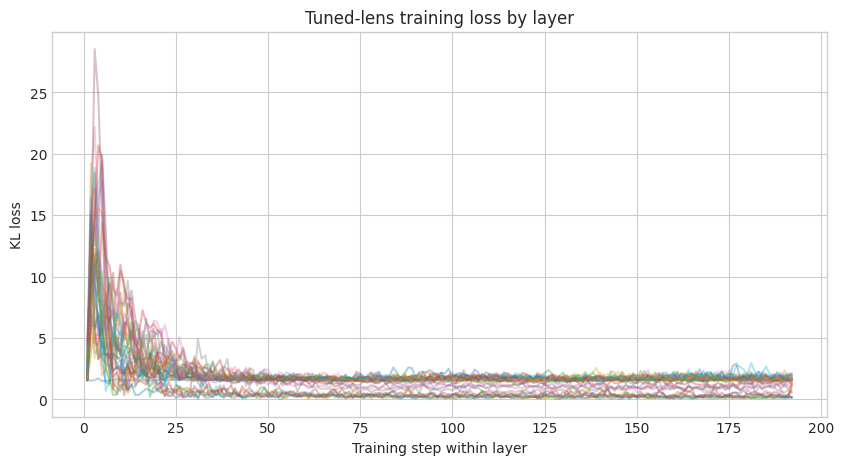

,layer,best_epoch,best_step_in_layer,best_kl_loss,final_epoch,final_step_in_layer,final_kl_loss
0,0,2,112,1.479872,3,192,1.533655
1,1,3,172,1.493386,3,192,1.851603
2,2,2,126,1.457492,3,192,1.682187
3,3,2,78,1.444313,3,192,1.670570
4,4,3,184,1.487906,3,192,1.997388
5,5,3,155,1.426564,3,192,1.633585
6,6,3,168,1.458175,3,192,1.678713
7,7,2,72,1.470305,3,192,1.549292
8,8,1,32,1.472143,3,192,1.995568
9,9,3,154,1.488503,3,192,1.910331


In [7]:
plt.figure(figsize=(10, 5))
for li, g in train_history_df.groupby("layer"):
    plt.plot(g["step_in_layer"], g["kl_loss"], alpha=0.35)
plt.xlabel("Training step within layer")
plt.ylabel("KL loss")
plt.title("Tuned-lens training loss by layer")
plt.show()

best_rows = (
    train_history_df.loc[train_history_df.groupby("layer")["kl_loss"].idxmin()]
    .sort_values("layer")
    .rename(
        columns={
            "step_in_layer": "best_step_in_layer",
            "epoch": "best_epoch",
            "kl_loss": "best_kl_loss",
        }
    )[["layer", "best_epoch", "best_step_in_layer", "best_kl_loss"]]
)

final_rows = (
    train_history_df.sort_values(["layer", "step_in_layer"])
    .groupby("layer")
    .tail(1)
    .rename(
        columns={
            "step_in_layer": "final_step_in_layer",
            "epoch": "final_epoch",
            "kl_loss": "final_kl_loss",
        }
    )[["layer", "final_epoch", "final_step_in_layer", "final_kl_loss"]]
)

training_summary = best_rows.merge(final_rows, on="layer", how="inner")
display(training_summary.head(10).round(6))


## Direct Vs Tuned Summary

This is a compact sanity check before the trace analysis.

The direct readout uses the raw layer state plus the model's output mapping.
The tuned readout uses the trained layer translators.

After this point, the notebook proceeds with the tuned readout only.


In [8]:
def evaluate_method(cache, method_name):
    n = cache["hidden"].shape[0]
    true_choice_idx = cache["true_choice_idx"].numpy()
    final_choice_probs = cache["final_choice_probs"].numpy().astype(np.float32)

    answer_choice_entropy = np.zeros((n, L_plus_1), dtype=np.float32)
    answer_choice_entropy_norm = np.zeros((n, L_plus_1), dtype=np.float32)
    full_vocab_entropy = np.zeros((n, L_plus_1), dtype=np.float32)
    full_vocab_entropy_norm = np.zeros((n, L_plus_1), dtype=np.float32)
    answer_choice_gap = np.zeros((n, L_plus_1), dtype=np.float32)
    true_answer_prob = np.zeros((n, L_plus_1), dtype=np.float32)
    true_answer_rank = np.zeros((n, L_plus_1), dtype=np.float32)
    choice_kl_to_final = np.zeros((n, L_plus_1), dtype=np.float32)
    predicted_choice_index = np.zeros((n, L_plus_1), dtype=np.int64)

    for li in tqdm(range(L_plus_1), desc=f"evaluate {method_name}"):
        batch_logits = []
        batch_full_entropy = []
        for start in range(0, n, TUNED_LENS_BATCH_SIZE):
            xb = cache["hidden"][start:start + TUNED_LENS_BATCH_SIZE, li, :].float().to(train_device)

            if method_name == "direct":
                readout = maybe_apply_final_norm_cpu(xb, li)
            elif method_name == "tuned":
                if li == L:
                    readout = maybe_apply_final_norm_cpu(xb, li)
                else:
                    readout = lenses[li](xb)
            else:
                raise ValueError(method_name)

            full_logits = torch.matmul(readout, lm_head_weight_train.T)
            full_log_probs = torch.log_softmax(full_logits, dim=-1)
            full_probs = torch.exp(full_log_probs)
            full_entropy_batch = -(full_probs * full_log_probs).sum(dim=-1)
            batch_full_entropy.append(full_entropy_batch.detach().cpu())

            logits = torch.matmul(readout, answer_choice_weight_train.T)
            batch_logits.append(logits.detach().cpu())

        full_entropy_vals = torch.cat(batch_full_entropy, dim=0).numpy().astype(np.float32)
        choice_logits = torch.cat(batch_logits, dim=0).numpy().astype(np.float32)
        choice_log_probs = choice_logits - np.logaddexp.reduce(choice_logits, axis=1, keepdims=True)
        choice_probs = np.exp(choice_log_probs)

        full_vocab_entropy[:, li] = full_entropy_vals
        full_vocab_entropy_norm[:, li] = full_entropy_vals / log_full_vocab_count
        answer_choice_entropy[:, li] = -(choice_probs * choice_log_probs).sum(axis=1)
        answer_choice_entropy_norm[:, li] = answer_choice_entropy[:, li] / log_answer_choice_count
        sorted_choice = np.sort(choice_logits, axis=1)[:, ::-1]
        answer_choice_gap[:, li] = sorted_choice[:, 0] - sorted_choice[:, 1]
        predicted_choice_index[:, li] = np.argmax(choice_logits, axis=1)
        true_answer_prob[:, li] = choice_probs[np.arange(n), true_choice_idx]
        true_answer_rank[:, li] = 1 + (choice_logits > choice_logits[np.arange(n), true_choice_idx][:, None]).sum(axis=1)
        choice_kl_to_final[:, li] = np.sum(
            final_choice_probs * (np.log(np.clip(final_choice_probs, 1e-12, None)) - choice_log_probs),
            axis=1,
        )

    rows = []
    for i in range(n):
        pred_curve = predicted_choice_index[i]
        final_pred_idx = int(pred_curve[-1])
        final_pred_letter = LETTERS[final_pred_idx]
        agreement_with_final_curve = (pred_curve == final_pred_idx)
        final_rank = int(true_answer_rank[i, -1])

        rows.append(
            {
                "method": method_name,
                "example_id": cache["example_id"][i],
                "answerKey": cache["answerKey"][i],
                "final_answer_choice_prediction": final_pred_letter,
                "final_answer_choice_is_correct": bool(final_pred_letter == cache["answerKey"][i]),
                "answer_choice_rank_bucket": rank_bucket(final_rank),
                "final_answer_choice_true_rank": final_rank,
                "answer_choice_hit_at_2": bool(final_rank <= 2),
                "answer_choice_hit_at_3": bool(final_rank <= 3),
                "final_full_vocab_entropy_normalized": float(full_vocab_entropy_norm[i, -1]),
                "final_answer_choice_entropy_normalized": float(answer_choice_entropy_norm[i, -1]),
                "final_answer_choice_top1_top2_logit_gap": float(answer_choice_gap[i, -1]),
                "final_true_answer_probability_within_choices": float(true_answer_prob[i, -1]),
                "mean_choice_kl_to_final": float(choice_kl_to_final[i, :-1].mean()),
                "mean_layerwise_hit_at_1": float((true_answer_rank[i] <= 1).mean()),
                "mean_layerwise_hit_at_2": float((true_answer_rank[i] <= 2).mean()),
                "mean_layerwise_hit_at_3": float((true_answer_rank[i] <= 3).mean()),
                "answer_choice_prediction_flip_count": int(np.sum(pred_curve[1:] != pred_curve[:-1])),
                "first_answer_choice_prediction_stable_layer": first_numeric_stable(pred_curve),
                "first_low_answer_choice_entropy_layer": first_threshold_crossing(answer_choice_entropy_norm[i], ANSWER_CHOICE_ENTROPY_SATURATION_THRESHOLD, direction="le"),
                "answer_choice_gap_stable_layer": first_threshold_stable(answer_choice_gap[i], ANSWER_CHOICE_GAP_STABILITY_THRESHOLD, direction="ge"),
                "true_answer_rank_stable_layer": first_numeric_stable(true_answer_rank[i]),
                "first_answer_choice_agreement_with_final_layer": first_true(agreement_with_final_curve),
                "stable_answer_choice_agreement_with_final_layer": first_stable(agreement_with_final_curve),
                "full_vocab_entropy_curve": full_vocab_entropy[i].copy(),
                "full_vocab_entropy_normalized_curve": full_vocab_entropy_norm[i].copy(),
                "full_vocab_entropy_change_curve": np.diff(full_vocab_entropy[i]).astype(np.float32),
                "full_vocab_entropy_normalized_change_curve": np.diff(full_vocab_entropy_norm[i]).astype(np.float32),
                "answer_choice_entropy_curve": answer_choice_entropy[i].copy(),
                "answer_choice_entropy_normalized_curve": answer_choice_entropy_norm[i].copy(),
                "answer_choice_top1_top2_logit_gap_curve": answer_choice_gap[i].copy(),
                "true_answer_probability_within_choices_curve": true_answer_prob[i].copy(),
                "true_answer_rank_within_choices_curve": true_answer_rank[i].copy(),
                "choice_kl_to_final_curve": choice_kl_to_final[i].copy(),
                "answer_choice_prediction_index_curve": pred_curve.copy(),
                "answer_choice_prediction_agreement_with_final_curve": agreement_with_final_curve.astype(np.float32),
            }
        )

    return pd.DataFrame(rows)


direct_df = evaluate_method(eval_cache, "direct")
tuned_df = evaluate_method(eval_cache, "tuned")

summary_rows = []
for method_name, frame in [("direct", direct_df), ("tuned", tuned_df)]:
    summary_rows.append(
        {
            "method": method_name,
            "mean_choice_kl_to_final": float(frame["mean_choice_kl_to_final"].mean()),
            "mean_layerwise_hit_at_1": float(frame["mean_layerwise_hit_at_1"].mean()),
            "mean_layerwise_hit_at_2": float(frame["mean_layerwise_hit_at_2"].mean()),
            "mean_layerwise_hit_at_3": float(frame["mean_layerwise_hit_at_3"].mean()),
            "final_hit_at_1": float(frame["final_answer_choice_is_correct"].mean()),
            "final_hit_at_2": float(frame["answer_choice_hit_at_2"].mean()),
            "final_hit_at_3": float(frame["answer_choice_hit_at_3"].mean()),
        }
    )

direct_vs_tuned_summary = pd.DataFrame(summary_rows)
display(direct_vs_tuned_summary.round(4))


evaluate tuned: 100%|██████████| 37/37 [00:06<00:00,  5.92it/s]


,method,mean_choice_kl_to_final,mean_layerwise_hit_at_1,mean_layerwise_hit_at_2,mean_layerwise_hit_at_3,final_hit_at_1,final_hit_at_2,final_hit_at_3
0,direct,2.2369,0.3204,0.5017,0.6682,0.8026,0.9345,0.9697
1,tuned,1.3832,0.3915,0.5800,0.7311,0.8026,0.9345,0.9697


## Tuned Trace Analysis Setup

From here on, the notebook uses only the tuned readout.
The final buckets are still:

- rank1_correct
- rank2_near_miss
- rank3plus_hard


In [9]:
analysis_df = tuned_df.copy()
bucket_order = ["rank1_correct", "rank2_near_miss", "rank3plus_hard"]
bucket_colors = {
    "rank1_correct": "#2a9d8f",
    "rank2_near_miss": "#e9c46a",
    "rank3plus_hard": "#e76f51",
}

display(
    pd.DataFrame(
        {
            "count": analysis_df["answer_choice_rank_bucket"].value_counts().reindex(bucket_order),
            "share": analysis_df["answer_choice_rank_bucket"].value_counts(normalize=True).reindex(bucket_order),
        }
    ).round(4)
)


,count,share
answer_choice_rank_bucket,,
rank1_correct,980,0.8026
rank2_near_miss,161,0.1319
rank3plus_hard,80,0.0655


## Final-Layer Summary By Bucket

This table shows how the final tuned readout differs between correct, near-miss, and hard-miss examples.


In [10]:
summary_cols = [
    "final_full_vocab_entropy_normalized",
    "final_answer_choice_entropy_normalized",
    "final_answer_choice_top1_top2_logit_gap",
    "final_true_answer_probability_within_choices",
    "answer_choice_prediction_flip_count",
    "first_answer_choice_prediction_stable_layer",
    "first_answer_choice_agreement_with_final_layer",
    "stable_answer_choice_agreement_with_final_layer",
]

display(
    analysis_df.groupby("answer_choice_rank_bucket")[summary_cols]
    .agg(["mean", "median", "std"])
    .round(4)
)


final_full_vocab_entropy_normalized                 final_answer_choice_entropy_normalized                 final_answer_choice_top1_top2_logit_gap  \
                                                         mean  median     std                                   mean  median     std                                    mean   
answer_choice_rank_bucket                                                                                                                                                      
rank1_correct                                          0.0036  0.0002  0.0113                                 0.0223  0.0001  0.0769                                 10.7519   
rank2_near_miss                                        0.0150  0.0029  0.0221                                 0.0975  0.0143  0.1482                                  6.2351   
rank3plus_hard                                         0.0191  0.0028  0.0273                                 0.1260  0.0110  0.1863                                  6.3280   

                                           final_true_answer_probability_within_choices                 answer_choice_prediction_flip_count                 \
                            median     std                                         mean  median     std                                mean median     std   
answer_choice_rank_bucket                                                                                                                                    
rank1_correct              11.8922  3.8782                                       0.9863  1.0000  0.0588                             19.9847   20.0  2.5749   
rank2_near_miss             5.7513  3.9723                                       0.0600  0.0032  0.1113                             20.8696   21.0  3.0293   
rank3plus_hard              6.3811  4.4416                                       0.0049  0.0000  0.0206                             21.2375   21.0  2.9089   

                          first_answer_choice_prediction_stable_layer                first_answer_choice_agreement_with_final_layer                 \
                                                                 mean median     std                                           mean median     std   
answer_choice_rank_bucket                                                                                                                            
rank1_correct                                                 26.4878   27.0  2.9740                                         4.0163    2.0  5.0442   
rank2_near_miss                                               28.7267   28.0  3.7081                                         3.1863    1.0  4.3963   
rank3plus_hard                                                29.1375   28.0  3.8640                                         4.8000    2.0  6.3533   

                          stable_answer_choice_agreement_with_final_layer                 
                                                                     mean median     std  
answer_choice_rank_bucket                                                                 
rank1_correct                                                     26.4878   27.0  2.9740  
rank2_near_miss                                                   28.7267   28.0  3.7081  
rank3plus_hard                                                    29.1375   28.0  3.8640

## Entropy Over Layers

This section tracks uncertainty inside the A-E answer-choice space only.
A lower curve means the model is becoming more committed among the five answer options.


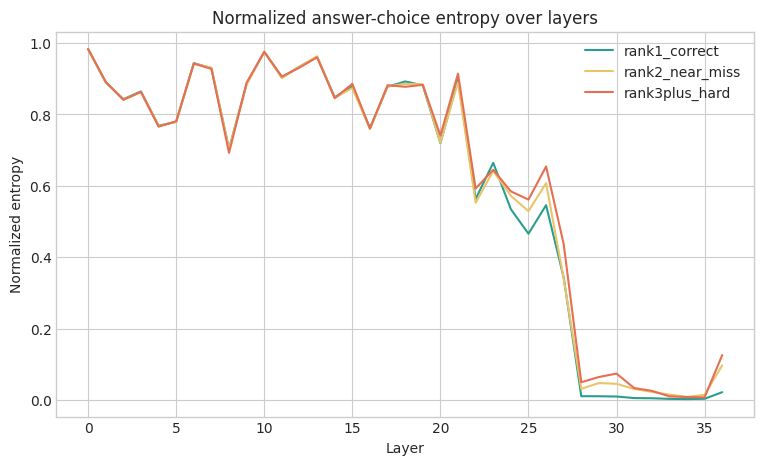

In [11]:
layers = np.arange(L_plus_1)


def stack_curve(col):
    return np.stack(analysis_df[col].to_list(), axis=0)


def mean_curve(col, bucket):
    mat = stack_curve(col)
    mask = analysis_df["answer_choice_rank_bucket"].eq(bucket).to_numpy()
    return mat[mask].mean(axis=0)


entropy_curve_col = "answer_choice_entropy_normalized_curve"

plt.figure(figsize=(9, 5))
for bucket in bucket_order:
    plt.plot(layers, mean_curve(entropy_curve_col, bucket), label=bucket, color=bucket_colors[bucket])
plt.xlabel("Layer")
plt.ylabel("Normalized entropy")
plt.title("Normalized answer-choice entropy over layers")
plt.legend()
plt.show()


## Entropy Over Layers: Correct Vs Incorrect

This view collapses the rank buckets into a simpler split:

- correct final answer
- incorrect final answer

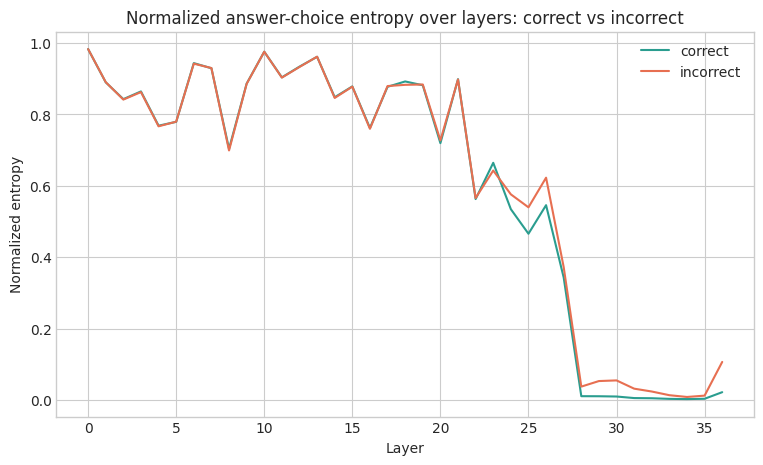

In [12]:
correct_mask = analysis_df["final_answer_choice_is_correct"].to_numpy()
incorrect_mask = ~correct_mask
entropy_mat = stack_curve("answer_choice_entropy_normalized_curve")

plt.figure(figsize=(9, 5))
plt.plot(layers, entropy_mat[correct_mask].mean(axis=0), label="correct", color="#2a9d8f")
plt.plot(layers, entropy_mat[incorrect_mask].mean(axis=0), label="incorrect", color="#e76f51")
plt.xlabel("Layer")
plt.ylabel("Normalized entropy")
plt.title("Normalized answer-choice entropy over layers: correct vs incorrect")
plt.legend()
plt.show()

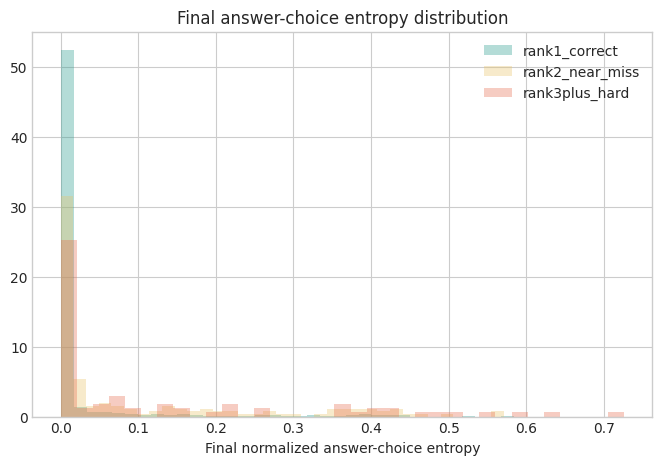

In [13]:
plt.figure(figsize=(8, 5))
for bucket in bucket_order:
    vals = pd.to_numeric(
        analysis_df.loc[analysis_df["answer_choice_rank_bucket"].eq(bucket), "final_answer_choice_entropy_normalized"],
        errors="coerce",
    ).dropna()
    plt.hist(vals, bins=35, density=True, alpha=0.35, label=bucket, color=bucket_colors[bucket])
plt.xlabel("Final normalized answer-choice entropy")
plt.title("Final answer-choice entropy distribution")
plt.legend()
plt.show()

## Full-Vocabulary Entropy Over Layers

This section mirrors the answer-choice entropy view, but now entropy is computed over the full decoded vocabulary.

That gives a broader picture of how diffuse or concentrated the decoded residual-stream distribution is at each layer.

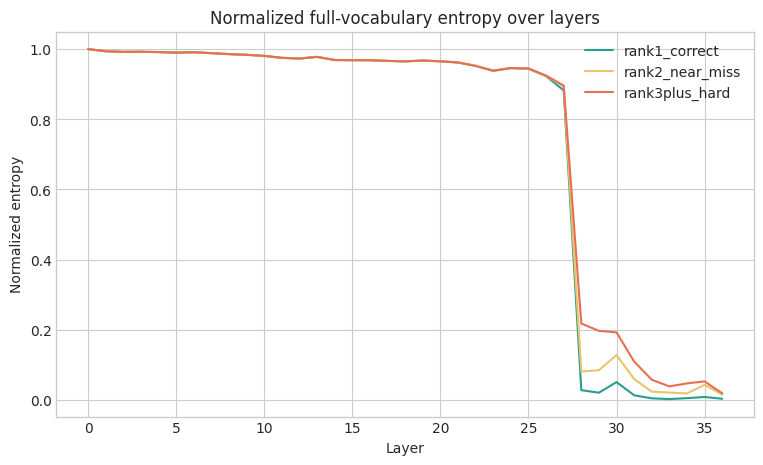

In [14]:
full_entropy_curve_col = "full_vocab_entropy_normalized_curve"

plt.figure(figsize=(9, 5))
for bucket in bucket_order:
    plt.plot(layers, mean_curve(full_entropy_curve_col, bucket), label=bucket, color=bucket_colors[bucket])
plt.xlabel("Layer")
plt.ylabel("Normalized entropy")
plt.title("Normalized full-vocabulary entropy over layers")
plt.legend()
plt.show()

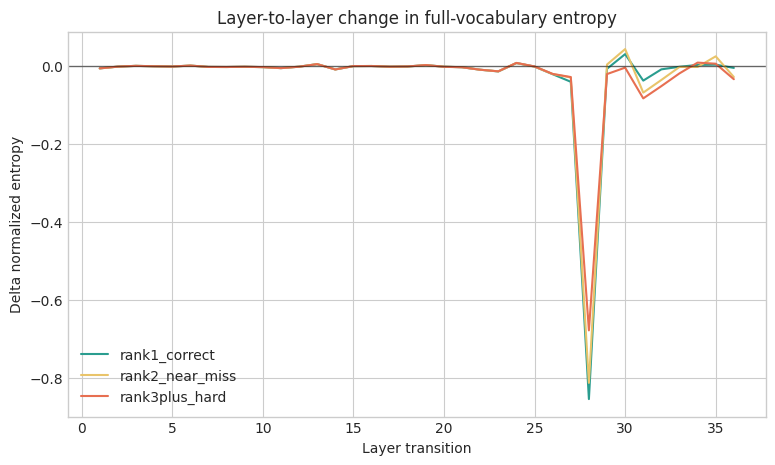

In [15]:
delta_layers = np.arange(1, L_plus_1)
full_entropy_delta_col = "full_vocab_entropy_normalized_change_curve"

plt.figure(figsize=(9, 5))
for bucket in bucket_order:
    plt.plot(delta_layers, mean_curve(full_entropy_delta_col, bucket), label=bucket, color=bucket_colors[bucket])
plt.axhline(0.0, color="black", linewidth=1, alpha=0.5)
plt.xlabel("Layer transition")
plt.ylabel("Delta normalized entropy")
plt.title("Layer-to-layer change in full-vocabulary entropy")
plt.legend()
plt.show()

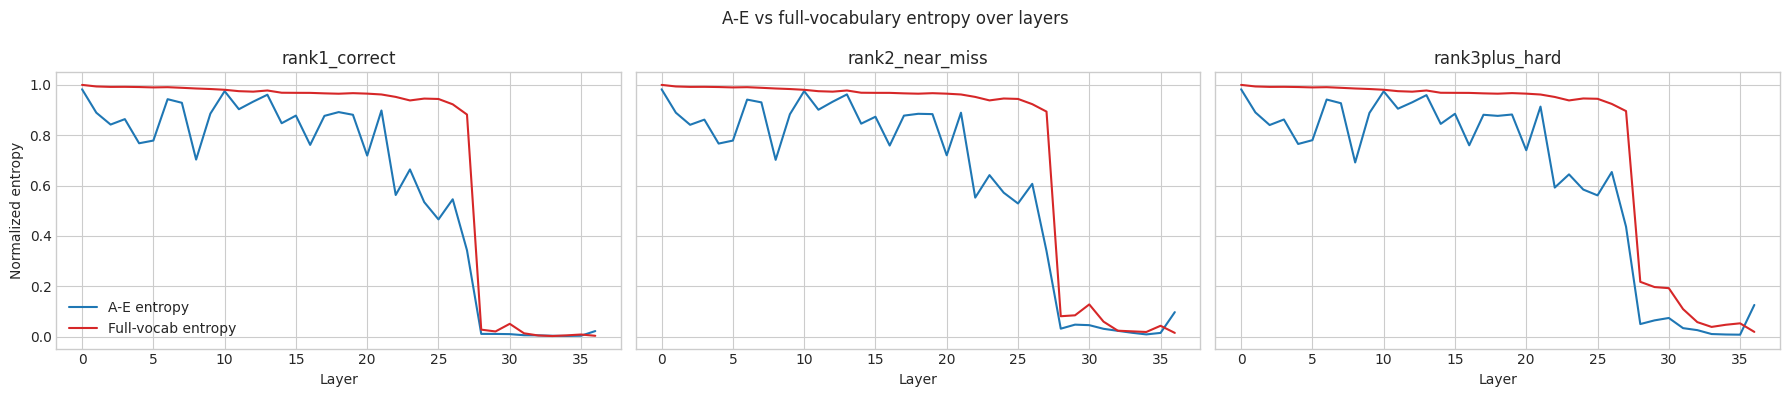

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, bucket in zip(axes, bucket_order):
    ax.plot(layers, mean_curve("answer_choice_entropy_normalized_curve", bucket), label="A-E entropy", color="#1f77b4")
    ax.plot(layers, mean_curve("full_vocab_entropy_normalized_curve", bucket), label="Full-vocab entropy", color="#d62728")
    ax.set_title(bucket)
    ax.set_xlabel("Layer")

axes[0].set_ylabel("Normalized entropy")
axes[0].legend()
plt.suptitle("A-E vs full-vocabulary entropy over layers")
plt.tight_layout()
plt.show()

## Logit Gap Over Layers

This section tracks the gap between the strongest and second-strongest answer choice.
A larger gap means the model is separating one option more clearly from the runner-up.


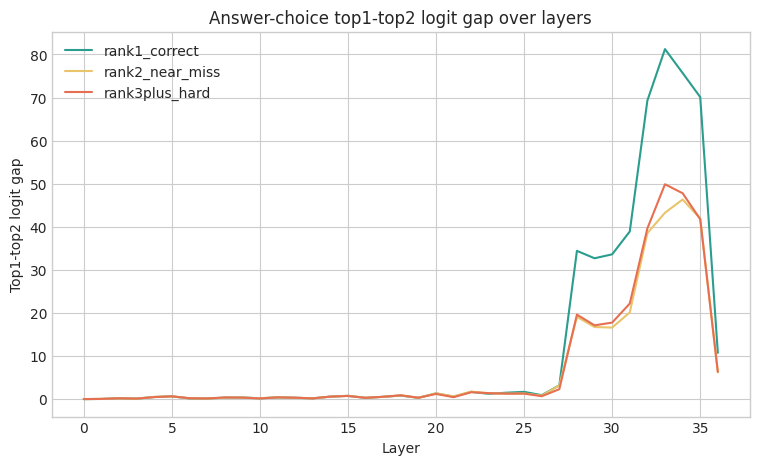

In [17]:
gap_curve_col = "answer_choice_top1_top2_logit_gap_curve"

plt.figure(figsize=(9, 5))
for bucket in bucket_order:
    plt.plot(layers, mean_curve(gap_curve_col, bucket), label=bucket, color=bucket_colors[bucket])
plt.xlabel("Layer")
plt.ylabel("Top1-top2 logit gap")
plt.title("Answer-choice top1-top2 logit gap over layers")
plt.legend()
plt.show()

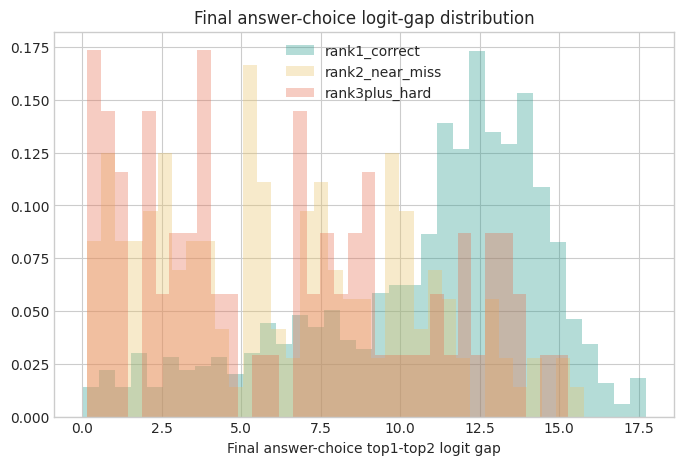

In [18]:
plt.figure(figsize=(8, 5))
for bucket in bucket_order:
    vals = pd.to_numeric(
        analysis_df.loc[analysis_df["answer_choice_rank_bucket"].eq(bucket), "final_answer_choice_top1_top2_logit_gap"],
        errors="coerce",
    ).dropna()
    plt.hist(vals, bins=35, density=True, alpha=0.35, label=bucket, color=bucket_colors[bucket])
plt.xlabel("Final answer-choice top1-top2 logit gap")
plt.title("Final answer-choice logit-gap distribution")
plt.legend()
plt.show()

## Residual Substep Margin Analysis

This section asks where inside each transformer block the correct answer gains or loses support.

We decode three residual checkpoints per layer:

- pre_attn
- post_attn
- post_mlp

For each checkpoint we measure only one quantity:

- correct_answer_margin_within_choices = logit(correct) - max(logit(other A-E choices))

This keeps the analysis focused on the decision competition inside the A-E answer space.

To keep all three checkpoints comparable, this section uses the model's direct output mapping rather than the tuned lens.

In [19]:
def decode_correct_margin_within_choices(hidden_batch, true_choice_idx_batch):
    hidden_batch = hidden_batch.float()
    if final_norm is not None:
        hidden_batch = final_norm(hidden_batch)
    choice_logits = torch.matmul(hidden_batch, answer_choice_weight_train.T)
    row_idx = torch.arange(choice_logits.shape[0], device=choice_logits.device)
    true_logits = choice_logits[row_idx, true_choice_idx_batch]
    other_logits = choice_logits.clone()
    other_logits[row_idx, true_choice_idx_batch] = -torch.inf
    best_other_logits = other_logits.max(dim=-1).values
    return (true_logits - best_other_logits).detach().cpu()


def extract_residual_substep_margin_rows(frame):
    rows = []

    handles = []
    cache = {"pre_attn": {}, "post_attn": {}, "post_mlp": {}}

    def clear_cache():
        for key in cache:
            cache[key].clear()

    for li, layer in enumerate(decoder_layers):
        def make_pre_attn_hook(idx):
            def hook(module, args):
                cache["pre_attn"][idx] = args[0].detach()
            return hook

        def make_post_attn_hook(idx):
            def hook(module, args):
                cache["post_attn"][idx] = args[0].detach()
            return hook

        def make_post_mlp_hook(idx):
            def hook(module, args, output):
                hidden = output[0] if isinstance(output, tuple) else output
                cache["post_mlp"][idx] = hidden.detach()
            return hook

        handles.append(layer.register_forward_pre_hook(make_pre_attn_hook(li)))
        if not hasattr(layer, "post_attention_layernorm"):
            raise ValueError("Expected post_attention_layernorm on decoder layer.")
        handles.append(layer.post_attention_layernorm.register_forward_pre_hook(make_post_attn_hook(li)))
        handles.append(layer.register_forward_hook(make_post_mlp_hook(li)))

    try:
        for start in tqdm(range(0, len(frame), RESIDUAL_SUBSTEP_BATCH_SIZE), total=int(math.ceil(len(frame) / RESIDUAL_SUBSTEP_BATCH_SIZE)), desc="extract residual substep margins"):
            batch_df = frame.iloc[start:start + RESIDUAL_SUBSTEP_BATCH_SIZE].reset_index(drop=True)
            batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
            decision_pos = batch_cpu.pop("decision_pos")
            batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
            decision_pos = decision_pos.to(model.device)
            true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=train_device)

            clear_cache()
            with torch.no_grad():
                _ = model(**batch, return_dict=True, use_cache=False)

            bsz = len(batch_df)
            row_idx = torch.arange(bsz, device=decision_pos.device)

            checkpoint_names = []
            checkpoint_margin_blocks = []
            attn_delta_blocks = []
            mlp_delta_blocks = []

            for li in range(L):
                pre_hidden = cache["pre_attn"][li][row_idx, decision_pos]
                post_attn_hidden = cache["post_attn"][li][row_idx, decision_pos]
                post_mlp_hidden = cache["post_mlp"][li][row_idx, decision_pos]

                pre_margin = decode_correct_margin_within_choices(pre_hidden.to(train_device), true_choice_idx).numpy().astype(np.float32)
                post_attn_margin = decode_correct_margin_within_choices(post_attn_hidden.to(train_device), true_choice_idx).numpy().astype(np.float32)
                post_mlp_margin = decode_correct_margin_within_choices(post_mlp_hidden.to(train_device), true_choice_idx).numpy().astype(np.float32)

                checkpoint_names.extend([f"pre_attn_{li+1}", f"post_attn_{li+1}", f"post_mlp_{li+1}"])
                checkpoint_margin_blocks.extend([pre_margin, post_attn_margin, post_mlp_margin])
                attn_delta_blocks.append((post_attn_margin - pre_margin).astype(np.float32))
                mlp_delta_blocks.append((post_mlp_margin - post_attn_margin).astype(np.float32))

            checkpoint_margin_matrix = np.stack(checkpoint_margin_blocks, axis=1)
            attn_delta_matrix = np.stack(attn_delta_blocks, axis=1)
            mlp_delta_matrix = np.stack(mlp_delta_blocks, axis=1)

            for bi in range(bsz):
                rows.append(
                    {
                        "example_id": batch_df.loc[bi, "example_id"],
                        "substep_checkpoint_names": checkpoint_names,
                        "correct_margin_checkpoint_curve": checkpoint_margin_matrix[bi].copy(),
                        "attention_margin_delta_curve": attn_delta_matrix[bi].copy(),
                        "mlp_margin_delta_curve": mlp_delta_matrix[bi].copy(),
                        "mean_attention_margin_delta": float(attn_delta_matrix[bi].mean()),
                        "mean_mlp_margin_delta": float(mlp_delta_matrix[bi].mean()),
                    }
                )
    finally:
        for handle in handles:
            handle.remove()

    return pd.DataFrame(rows)


residual_substep_df = extract_residual_substep_margin_rows(eval_rows)
analysis_df = analysis_df.merge(residual_substep_df, on="example_id", how="left", validate="one_to_one")


extract residual substep margins: 100%|██████████| 1221/1221 [01:27<00:00, 14.02it/s]


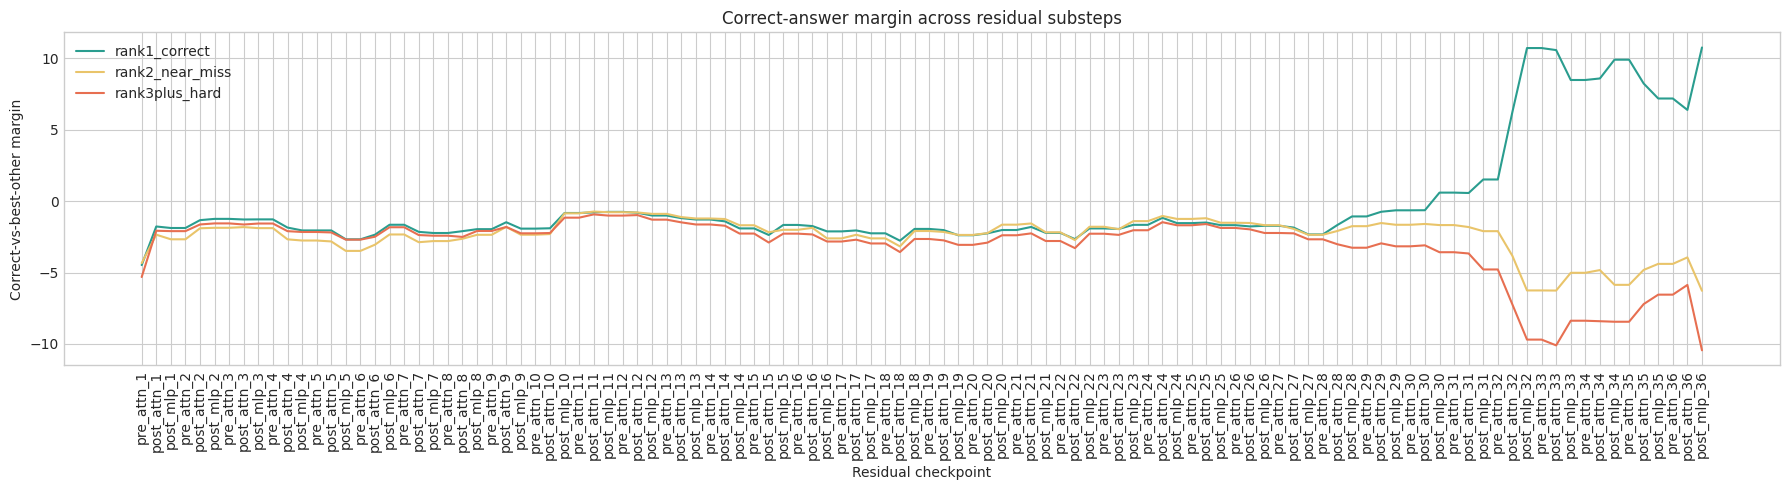

In [20]:
checkpoint_labels = analysis_df["substep_checkpoint_names"].iloc[0]
checkpoint_margin_mat = np.stack(analysis_df["correct_margin_checkpoint_curve"].to_list(), axis=0)

plt.figure(figsize=(18, 5))
for bucket in bucket_order:
    mask = analysis_df["answer_choice_rank_bucket"].eq(bucket).to_numpy()
    plt.plot(np.arange(len(checkpoint_labels)), checkpoint_margin_mat[mask].mean(axis=0), label=bucket, color=bucket_colors[bucket])
plt.xticks(np.arange(len(checkpoint_labels)), checkpoint_labels, rotation=90)
plt.xlabel("Residual checkpoint")
plt.ylabel("Correct-vs-best-other margin")
plt.title("Correct-answer margin across residual substeps")
plt.legend()
plt.tight_layout()
plt.show()


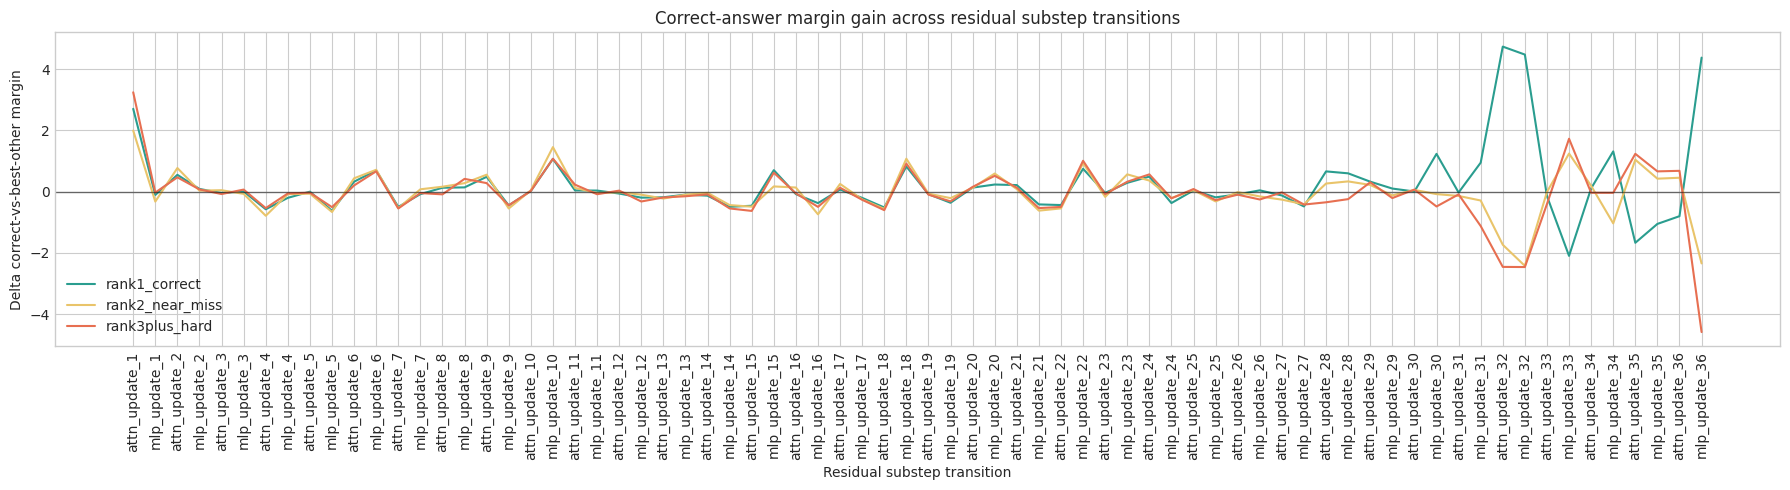

In [21]:
attn_delta_mat = np.stack(analysis_df["attention_margin_delta_curve"].to_list(), axis=0)
mlp_delta_mat = np.stack(analysis_df["mlp_margin_delta_curve"].to_list(), axis=0)
transition_labels = []
transition_mat_blocks = []

for li in range(L):
    transition_labels.extend([f"attn_update_{li+1}", f"mlp_update_{li+1}"])
    transition_mat_blocks.extend([attn_delta_mat[:, li], mlp_delta_mat[:, li]])

transition_mat = np.stack(transition_mat_blocks, axis=1)

plt.figure(figsize=(18, 5))
for bucket in bucket_order:
    mask = analysis_df["answer_choice_rank_bucket"].eq(bucket).to_numpy()
    plt.plot(np.arange(len(transition_labels)), transition_mat[mask].mean(axis=0), label=bucket, color=bucket_colors[bucket])
plt.axhline(0.0, color="black", linewidth=1, alpha=0.5)
plt.xticks(np.arange(len(transition_labels)), transition_labels, rotation=90)
plt.xlabel("Residual substep transition")
plt.ylabel("Delta correct-vs-best-other margin")
plt.title("Correct-answer margin gain across residual substep transitions")
plt.legend()
plt.tight_layout()
plt.show()


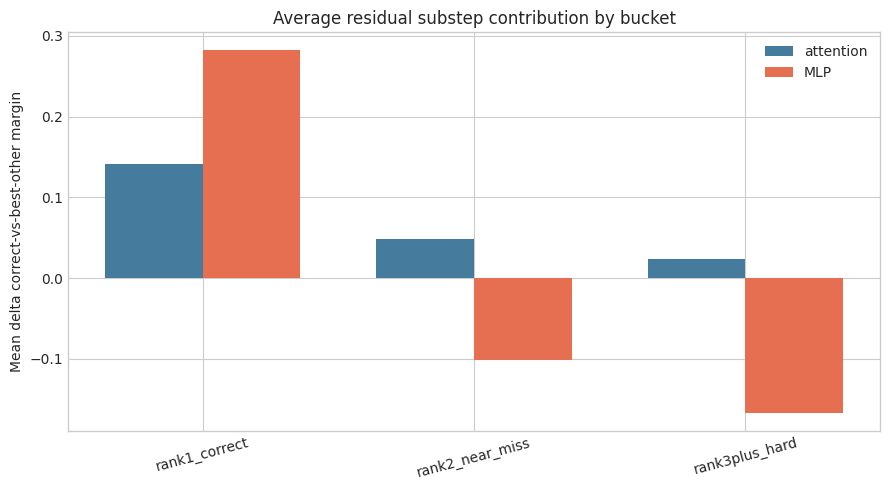

In [22]:
residual_delta_summary = (
    analysis_df.groupby("answer_choice_rank_bucket")[["mean_attention_margin_delta", "mean_mlp_margin_delta"]]
    .mean()
    .reindex(bucket_order)
)

x = np.arange(len(bucket_order))
width = 0.36

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, residual_delta_summary["mean_attention_margin_delta"].to_numpy(), width=width, label="attention", color="#457b9d")
plt.bar(x + width / 2, residual_delta_summary["mean_mlp_margin_delta"].to_numpy(), width=width, label="MLP", color="#e76f51")
plt.xticks(x, bucket_order, rotation=15)
plt.ylabel("Mean delta correct-vs-best-other margin")
plt.title("Average residual substep contribution by bucket")
plt.legend()
plt.tight_layout()
plt.show()


## Stability Over Layers

This section asks whether the A-E prediction keeps moving or settles early.

The main observable metrics are:

- answer_choice_prediction_flip_count
- first_answer_choice_prediction_stable_layer

A smaller number of flips and an earlier stable layer indicate a more settled decision trajectory.


In [23]:
stability_cols = [
    "answer_choice_prediction_flip_count",
    "first_answer_choice_prediction_stable_layer",
    "first_low_answer_choice_entropy_layer",
    "answer_choice_gap_stable_layer",
]

display(
    analysis_df.groupby("answer_choice_rank_bucket")[stability_cols]
    .agg(["mean", "median", "std"])
    .round(4)
)


answer_choice_prediction_flip_count                first_answer_choice_prediction_stable_layer                first_low_answer_choice_entropy_layer  \
                                                         mean median     std                                        mean median     std                                  mean   
answer_choice_rank_bucket                                                                                                                                                       
rank1_correct                                         19.9847   20.0  2.5749                                     26.4878   27.0  2.9740                               26.4541   
rank2_near_miss                                       20.8696   21.0  3.0293                                     28.7267   28.0  3.7081                               26.8012   
rank3plus_hard                                        21.2375   21.0  2.9089                                     29.1375   28.0  3.8640                               27.1125   

                                         answer_choice_gap_stable_layer                 
                          median     std                           mean median     std  
answer_choice_rank_bucket                                                               
rank1_correct               27.0  1.9905                        27.7171   28.0  0.8945  
rank2_near_miss             28.0  1.9584                        28.1667   28.0  1.5849  
rank3plus_hard              28.0  1.8623                        28.1818   28.0  1.4668

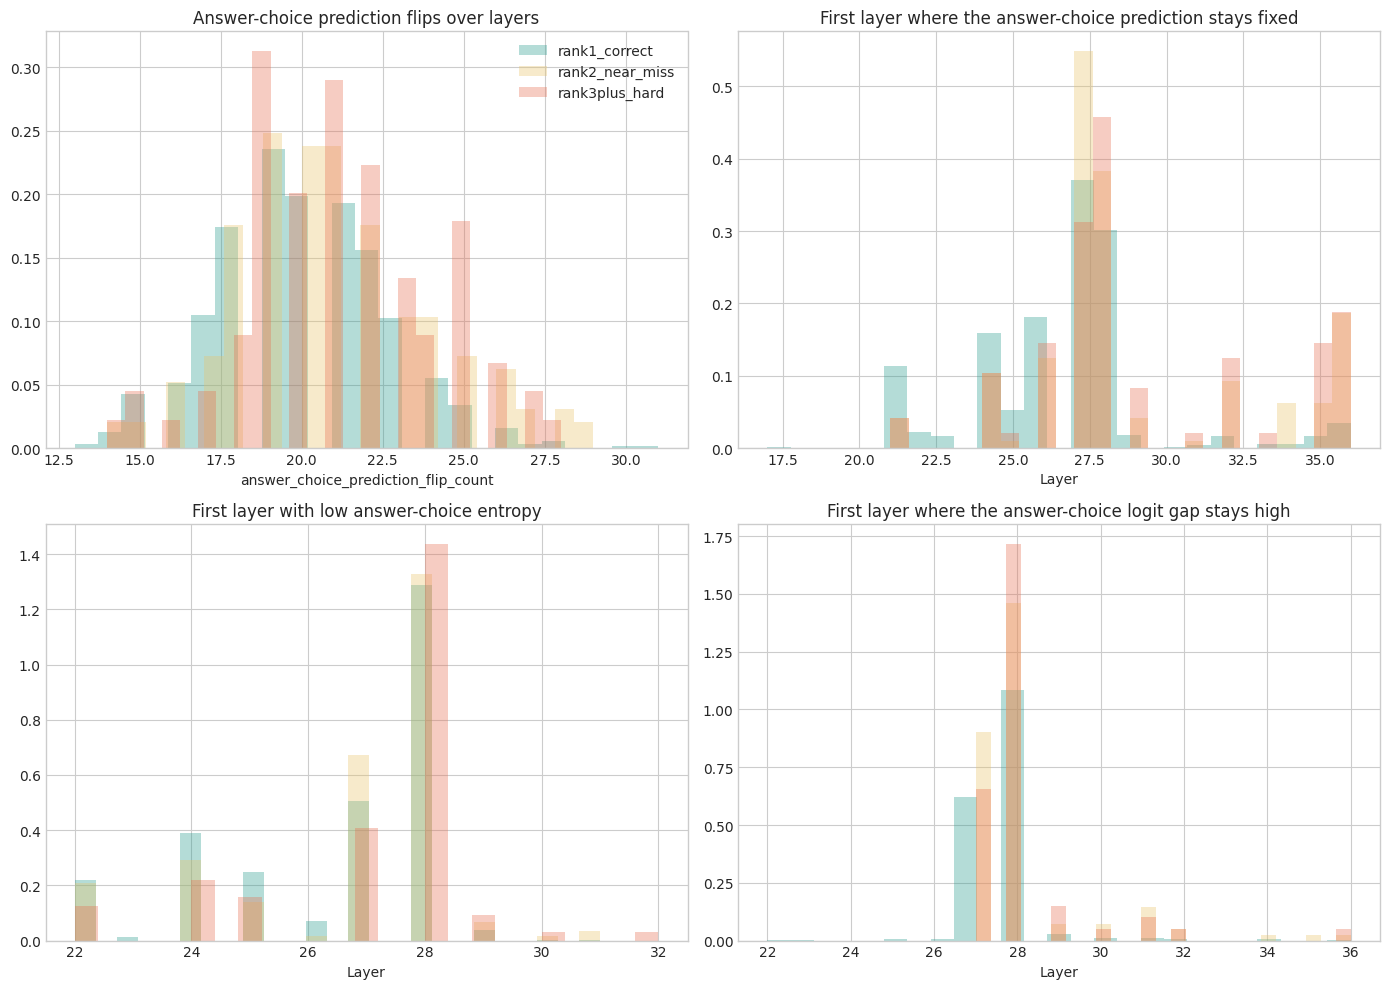

In [ ]:
stability_titles = {
    "answer_choice_prediction_flip_count": "Answer-choice prediction flips over layers",
    "first_answer_choice_prediction_stable_layer": "First layer where the answer-choice prediction stays fixed",
    "first_low_answer_choice_entropy_layer": "First layer with low answer-choice entropy",
    "answer_choice_gap_stable_layer": "First layer where the answer-choice logit gap stays high",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, stability_cols):
    for bucket in bucket_order:
        vals = pd.to_numeric(
            analysis_df.loc[analysis_df["answer_choice_rank_bucket"].eq(bucket), col],
            errors="coerce",
        ).dropna()
        ax.hist(vals, bins=25, density=True, alpha=0.35, color=bucket_colors[bucket], label=bucket)
    ax.set_title(stability_titles[col])
    ax.set_xlabel("Layer" if "layer" in col else col)

axes[0].legend()
plt.tight_layout()
plt.show()

## Agreement With The Final Prediction

This section measures when a layer already predicts the same A-E answer as the final tuned readout.

These are post-prediction validation features. They do not use the ground-truth answer.


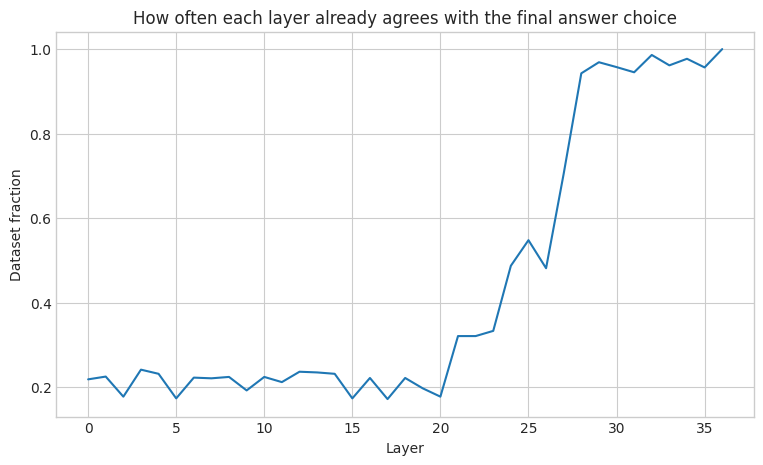

In [25]:
agreement_curve = stack_curve("answer_choice_prediction_agreement_with_final_curve")

plt.figure(figsize=(9, 5))
plt.plot(layers, agreement_curve.mean(axis=0))
plt.xlabel("Layer")
plt.ylabel("Dataset fraction")
plt.title("How often each layer already agrees with the final answer choice")
plt.show()


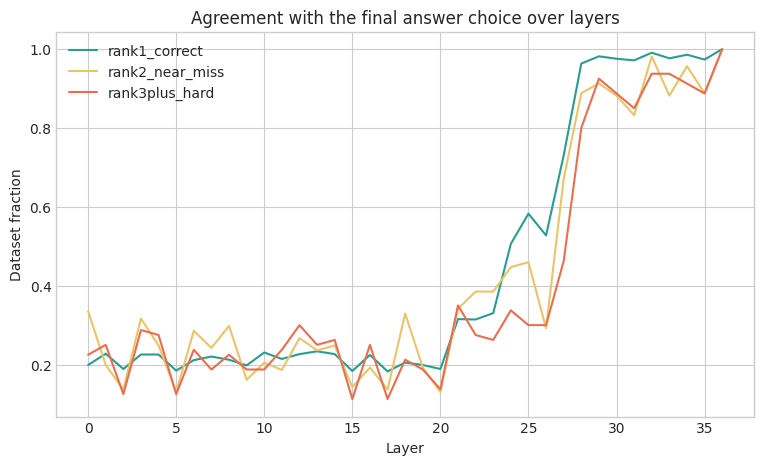

In [26]:
plt.figure(figsize=(9, 5))
for bucket in bucket_order:
    plt.plot(layers, mean_curve("answer_choice_prediction_agreement_with_final_curve", bucket), label=bucket, color=bucket_colors[bucket])
plt.xlabel("Layer")
plt.ylabel("Dataset fraction")
plt.title("Agreement with the final answer choice over layers")
plt.legend()
plt.show()


In [27]:
agreement_summary_cols = [
    "first_answer_choice_agreement_with_final_layer",
    "stable_answer_choice_agreement_with_final_layer",
]

display(
    analysis_df.groupby("answer_choice_rank_bucket")[agreement_summary_cols]
    .agg(["mean", "median", "std"])
    .round(4)
)


first_answer_choice_agreement_with_final_layer                stable_answer_choice_agreement_with_final_layer               
                                                                    mean median     std                                            mean median     std
answer_choice_rank_bucket                                                                                                                             
rank1_correct                                                     4.0163    2.0  5.0442                                         26.4878   27.0  2.9740
rank2_near_miss                                                   3.1863    1.0  4.3963                                         28.7267   28.0  3.7081
rank3plus_hard                                                    4.8000    2.0  6.3533                                         29.1375   28.0  3.8640

## Attention Section

This section analyzes attention from the decision position only.

It adds four attention-based views:

- decision-position per-head 2-Renyi entropy
- aggregated A-E choice-mass entropy
- aggregated A-E choice-mass top1-top2 gap
- attention agreement with the final answer choice

All task-specific attention features are computed only in the A-E answer-choice space.


In [28]:
choice_span_map = {
    row.example_id: build_choice_token_spans(row._asdict(), tok, MAX_SEQ_LEN)
    for row in eval_rows[["example_id", "text"]].itertuples(index=False)
}

final_choice_prediction_map = (
    analysis_df.set_index("example_id")["final_answer_choice_prediction"].to_dict()
)

attention_rows = []

for start in tqdm(range(0, len(eval_rows), ATTENTION_BATCH_SIZE), total=int(math.ceil(len(eval_rows) / ATTENTION_BATCH_SIZE)), desc="extract attention features"):
    batch_df = eval_rows.iloc[start:start + ATTENTION_BATCH_SIZE].reset_index(drop=True)
    batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
    decision_pos = batch_cpu.pop("decision_pos")
    batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
    decision_pos = decision_pos.to(model.device)

    with torch.no_grad():
        out = model(**batch, output_attentions=True, return_dict=True, use_cache=False)

    attentions = out.attentions

    for bi in range(len(batch_df)):
        example_id = batch_df.loc[bi, "example_id"]
        valid_len = int(batch_cpu["attention_mask"][bi].sum().item())
        pos = int(decision_pos[bi].item())
        choice_spans = choice_span_map[example_id]
        final_choice_idx = LETTERS.index(final_choice_prediction_map[example_id])

        head_renyi2_entropy_matrix = None
        mean_head_renyi2_entropy_curve = np.zeros(L, dtype=np.float32)
        aggregated_choice_attention_entropy_curve = np.zeros(L, dtype=np.float32)
        aggregated_choice_attention_top1_top2_gap_curve = np.zeros(L, dtype=np.float32)
        attention_choice_prediction_index_curve = np.zeros(L, dtype=np.int64)

        for li in range(L):
            attn_row = attentions[li][bi, :, pos, :valid_len].float().detach().cpu().numpy()
            squared_mass = np.sum(attn_row ** 2, axis=1)
            if valid_len > 1:
                renyi2 = -np.log(np.clip(squared_mass, 1e-12, None)) / np.log(valid_len)
            else:
                renyi2 = np.zeros(attn_row.shape[0], dtype=np.float32)
            if head_renyi2_entropy_matrix is None:
                head_renyi2_entropy_matrix = np.zeros((L, attn_row.shape[0]), dtype=np.float32)
            head_renyi2_entropy_matrix[li] = renyi2
            mean_head_renyi2_entropy_curve[li] = float(np.mean(renyi2))

            choice_mass_by_head = np.zeros((attn_row.shape[0], 5), dtype=np.float32)
            for ci, (span_start, span_end) in enumerate(choice_spans):
                if span_end > span_start:
                    choice_mass_by_head[:, ci] = attn_row[:, span_start:span_end].sum(axis=1)

            aggregated_choice_mass = choice_mass_by_head.mean(axis=0)
            if aggregated_choice_mass.sum() <= 0:
                aggregated_choice_probs = np.full(5, 1.0 / 5.0, dtype=np.float32)
            else:
                aggregated_choice_probs = aggregated_choice_mass / aggregated_choice_mass.sum()

            aggregated_choice_attention_entropy_curve[li] = float(
                -(aggregated_choice_probs * np.log(np.clip(aggregated_choice_probs, 1e-12, None))).sum() / log_answer_choice_count
            )
            sorted_probs = np.sort(aggregated_choice_probs)[::-1]
            aggregated_choice_attention_top1_top2_gap_curve[li] = float(sorted_probs[0] - sorted_probs[1])
            attention_choice_prediction_index_curve[li] = int(np.argmax(aggregated_choice_probs))

        attention_choice_agreement_with_final_curve = (
            attention_choice_prediction_index_curve == final_choice_idx
        )

        attention_rows.append(
            {
                "example_id": example_id,
                "head_renyi2_entropy_matrix": head_renyi2_entropy_matrix.copy(),
                "mean_head_renyi2_entropy_curve": mean_head_renyi2_entropy_curve,
                "aggregated_choice_attention_entropy_curve": aggregated_choice_attention_entropy_curve,
                "aggregated_choice_attention_top1_top2_gap_curve": aggregated_choice_attention_top1_top2_gap_curve,
                "attention_choice_prediction_index_curve": attention_choice_prediction_index_curve,
                "attention_choice_agreement_with_final_curve": attention_choice_agreement_with_final_curve.astype(np.float32),
                "final_mean_head_renyi2_entropy": float(mean_head_renyi2_entropy_curve[-1]),
                "final_aggregated_choice_attention_entropy": float(aggregated_choice_attention_entropy_curve[-1]),
                "final_aggregated_choice_attention_top1_top2_gap": float(aggregated_choice_attention_top1_top2_gap_curve[-1]),
                "first_attention_choice_agreement_with_final_layer": first_true(attention_choice_agreement_with_final_curve),
                "stable_attention_choice_agreement_with_final_layer": first_stable(attention_choice_agreement_with_final_curve),
            }
        )

attention_df = pd.DataFrame(attention_rows)
analysis_df = analysis_df.merge(attention_df, on="example_id", how="left", validate="one_to_one")

attention_summary_cols = [
    "final_mean_head_renyi2_entropy",
    "final_aggregated_choice_attention_entropy",
    "final_aggregated_choice_attention_top1_top2_gap",
    "first_attention_choice_agreement_with_final_layer",
    "stable_attention_choice_agreement_with_final_layer",
]

display(
    analysis_df.groupby("answer_choice_rank_bucket")[attention_summary_cols]
    .agg(["mean", "median", "std"])
    .round(4)
)


extract attention features: 100%|██████████| 1221/1221 [00:52<00:00, 23.05it/s]


final_mean_head_renyi2_entropy                 final_aggregated_choice_attention_entropy                  \
                                                    mean  median     std                                      mean  median     std   
answer_choice_rank_bucket                                                                                                            
rank1_correct                                     0.4978  0.4976  0.0259                                    0.9602  0.9644  0.0205   
rank2_near_miss                                   0.5032  0.5024  0.0237                                    0.9614  0.9636  0.0165   
rank3plus_hard                                    0.5083  0.5094  0.0266                                    0.9698  0.9711  0.0128   

                          final_aggregated_choice_attention_top1_top2_gap                 first_attention_choice_agreement_with_final_layer                  \
                                                                     mean  median     std                                              mean median      std   
answer_choice_rank_bucket                                                                                                                                     
rank1_correct                                                      0.0475  0.0382  0.0421                                           12.9421    7.0  12.1383   
rank2_near_miss                                                    0.0435  0.0364  0.0333                                           11.3000    7.0  12.9178   
rank3plus_hard                                                     0.0441  0.0366  0.0345                                           12.6974    7.0  12.6375   

                          stable_attention_choice_agreement_with_final_layer                 
                                                                        mean median     std  
answer_choice_rank_bucket                                                                    
rank1_correct                                                        32.2544   34.0  3.4332  
rank2_near_miss                                                      32.9455   35.0  2.9150  
rank3plus_hard                                                       33.0357   34.0  2.6872

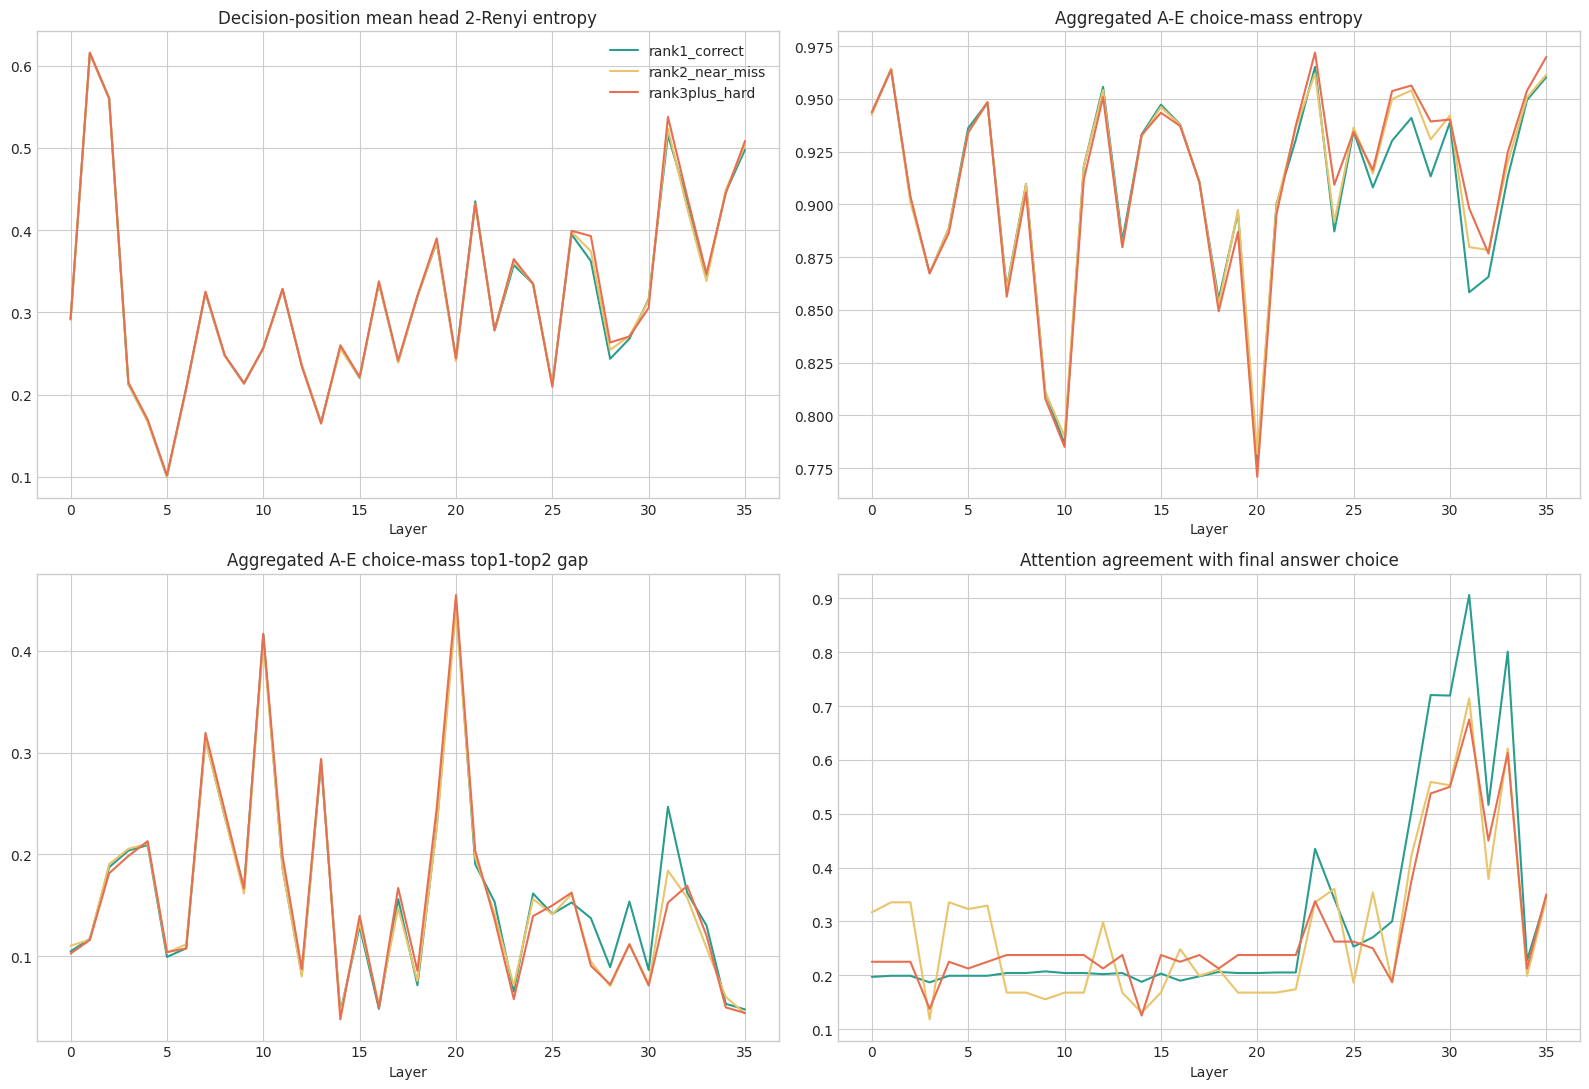

In [29]:
attention_layers = np.arange(L)


def stack_attention_curve(col):
    return np.stack(analysis_df[col].to_list(), axis=0)


attention_curve_specs = [
    ("mean_head_renyi2_entropy_curve", "Decision-position mean head 2-Renyi entropy"),
    ("aggregated_choice_attention_entropy_curve", "Aggregated A-E choice-mass entropy"),
    ("aggregated_choice_attention_top1_top2_gap_curve", "Aggregated A-E choice-mass top1-top2 gap"),
    ("attention_choice_agreement_with_final_curve", "Attention agreement with final answer choice"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.ravel()

for ax, (col, title) in zip(axes, attention_curve_specs):
    mat = stack_attention_curve(col)
    for bucket in bucket_order:
        mask = analysis_df["answer_choice_rank_bucket"].eq(bucket).to_numpy()
        ax.plot(attention_layers, mat[mask].mean(axis=0), label=bucket, color=bucket_colors[bucket])
    ax.set_title(title)
    ax.set_xlabel("Layer")

axes[0].legend()
plt.tight_layout()
plt.show()


### Per-Head Attention Entropy

This subsection keeps the full layer x head structure for the 2-Renyi entropy instead of collapsing heads inside each layer.

That lets us see whether specific heads behave differently across correct, near-miss, and hard-miss trajectories.


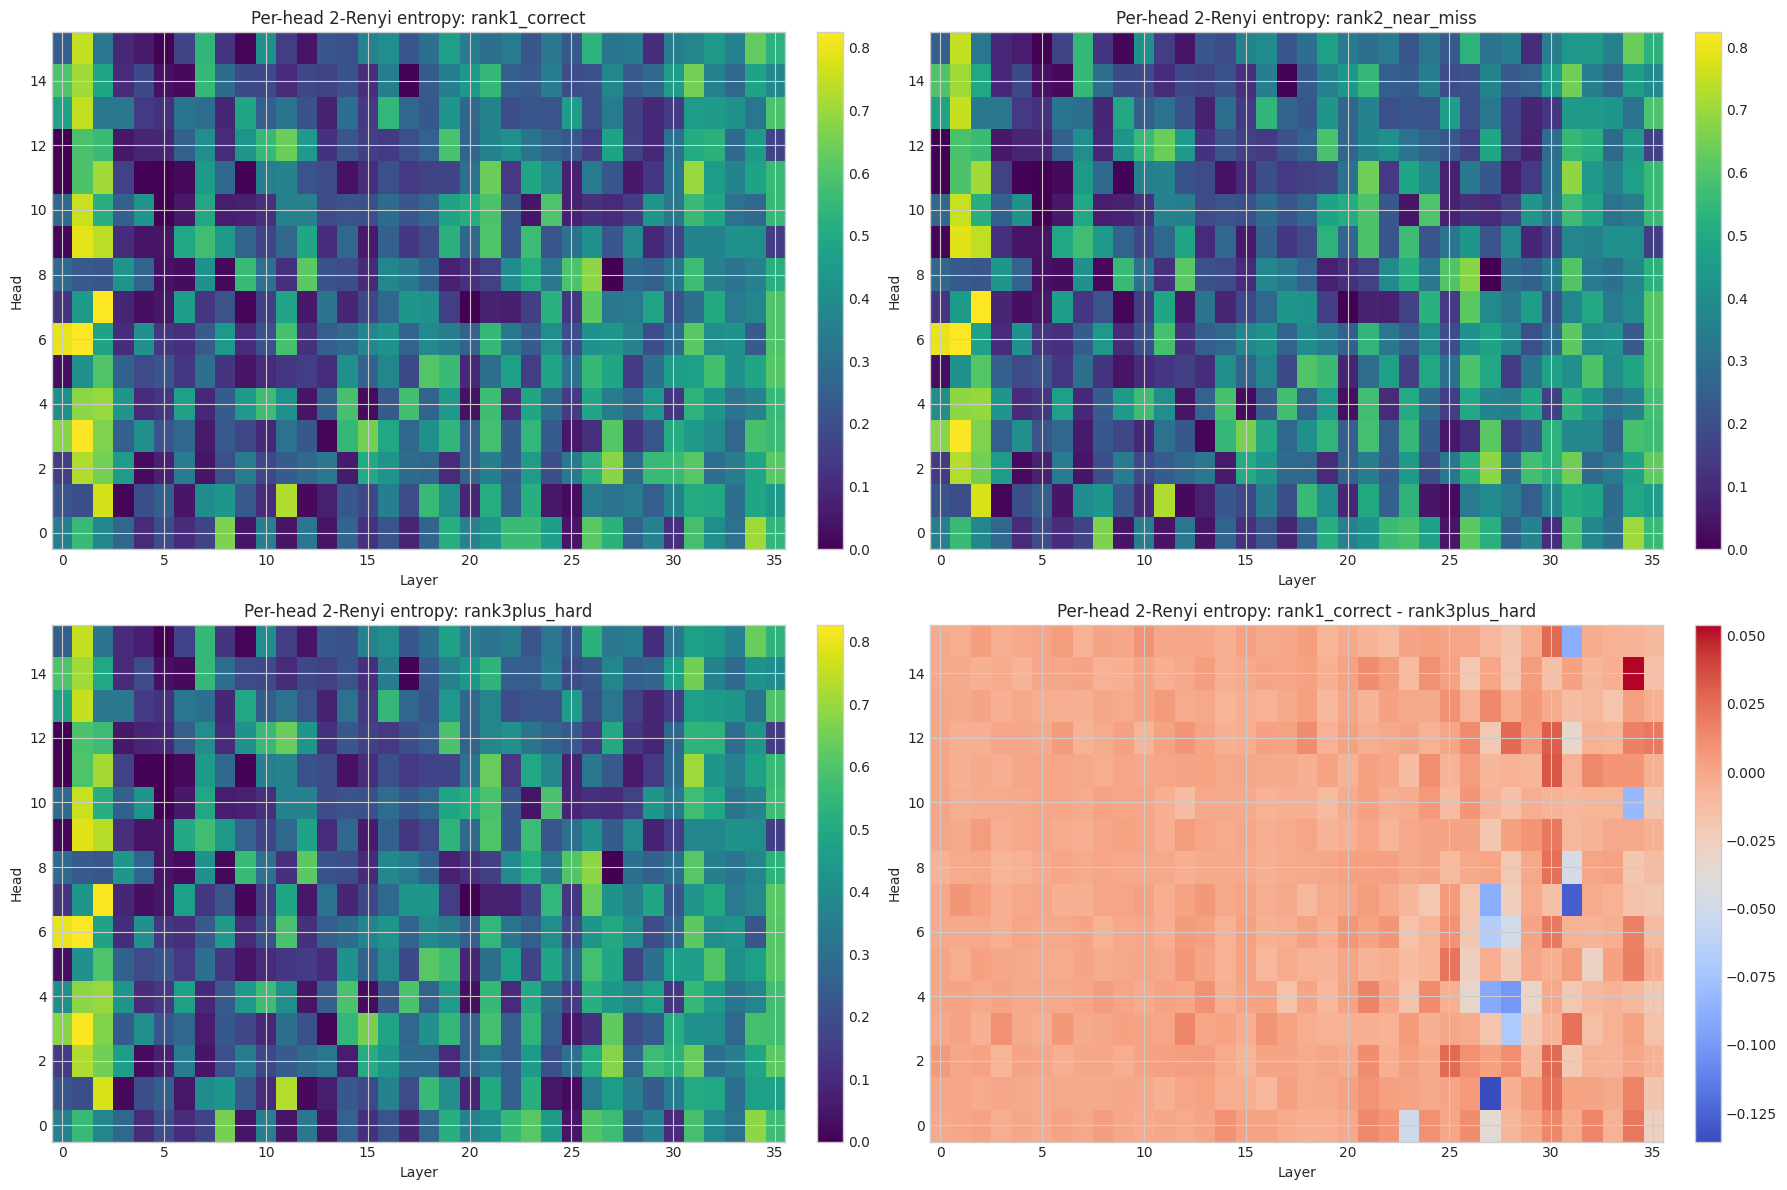

In [30]:
head_entropy_cube = np.stack(analysis_df["head_renyi2_entropy_matrix"].to_list(), axis=0)
n_heads = head_entropy_cube.shape[2]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

for ax, bucket in zip(axes[:3], bucket_order):
    mask = analysis_df["answer_choice_rank_bucket"].eq(bucket).to_numpy()
    heat = head_entropy_cube[mask].mean(axis=0)
    im = ax.imshow(heat.T, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(f"Per-head 2-Renyi entropy: {bucket}")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Head")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

rank1_mask = analysis_df["answer_choice_rank_bucket"].eq("rank1_correct").to_numpy()
rank3_mask = analysis_df["answer_choice_rank_bucket"].eq("rank3plus_hard").to_numpy()

if rank1_mask.any() and rank3_mask.any():
    diff_heat = head_entropy_cube[rank1_mask].mean(axis=0) - head_entropy_cube[rank3_mask].mean(axis=0)
    im = axes[3].imshow(diff_heat.T, aspect="auto", origin="lower", cmap="coolwarm")
    axes[3].set_title("Per-head 2-Renyi entropy: rank1_correct - rank3plus_hard")
    axes[3].set_xlabel("Layer")
    axes[3].set_ylabel("Head")
    plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
else:
    axes[3].axis("off")

plt.tight_layout()
plt.show()

## Hit@k Over Layers

This plot shows how often the true answer is already inside the top-k answer choices over depth.
It is still fully inside the A-E choice space.


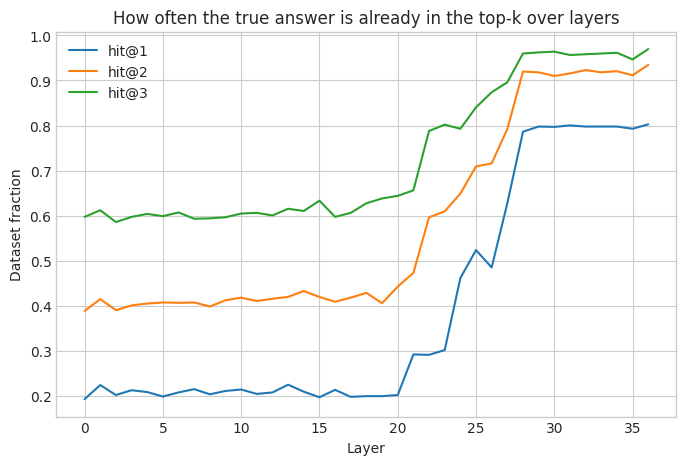

In [ ]:
rank_curve = stack_curve("true_answer_rank_within_choices_curve")

hit1 = (rank_curve <= 1).mean(axis=0)
hit2 = (rank_curve <= 2).mean(axis=0)
hit3 = (rank_curve <= 3).mean(axis=0)

plt.figure(figsize=(8, 5))
plt.plot(layers, hit1, label="hit@1")
plt.plot(layers, hit2, label="hit@2")
plt.plot(layers, hit3, label="hit@3")
plt.xlabel("Layer")
plt.ylabel("Dataset fraction")
plt.title("How often the true answer is already in the top-k over layers")
plt.legend()
plt.show()